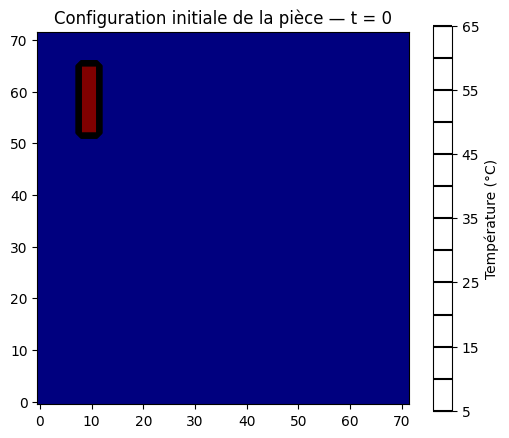

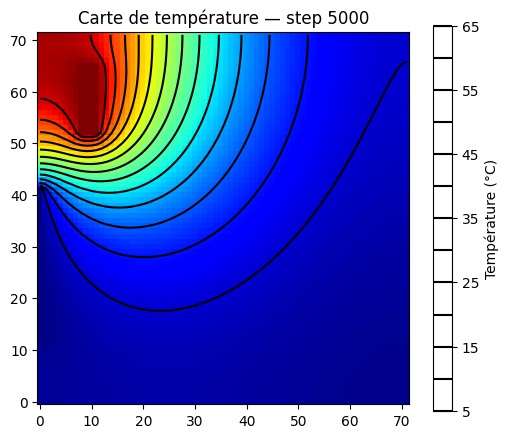

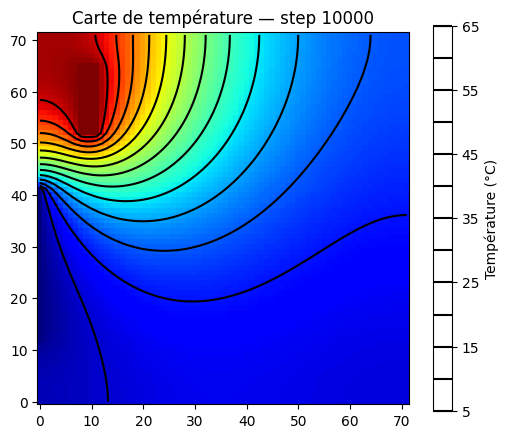

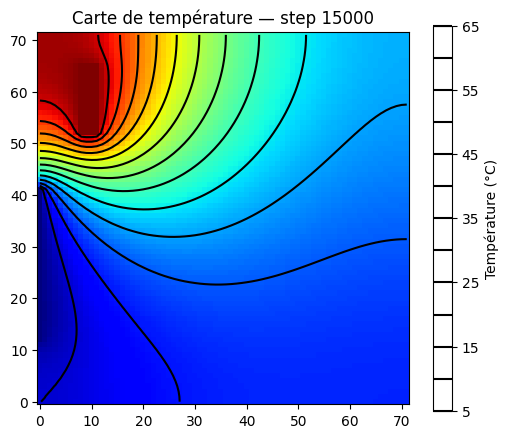

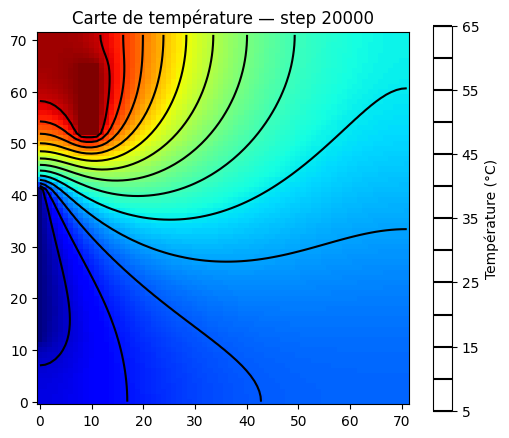

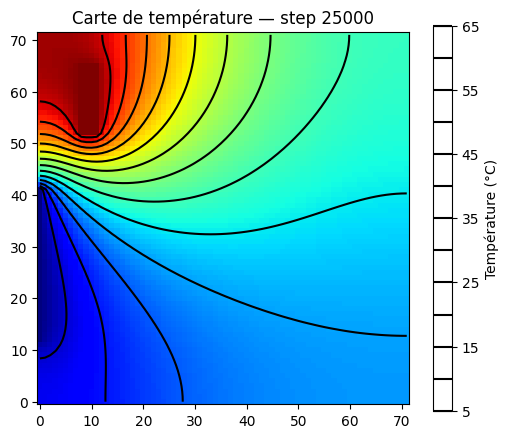

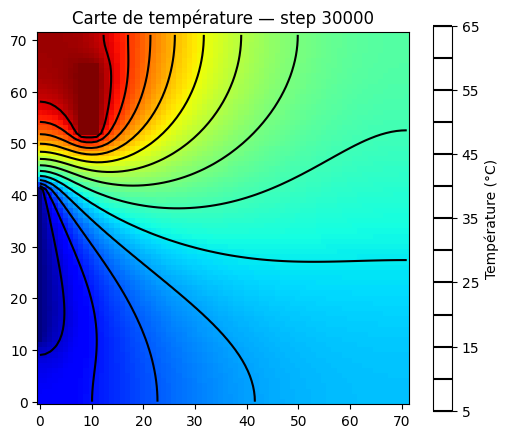

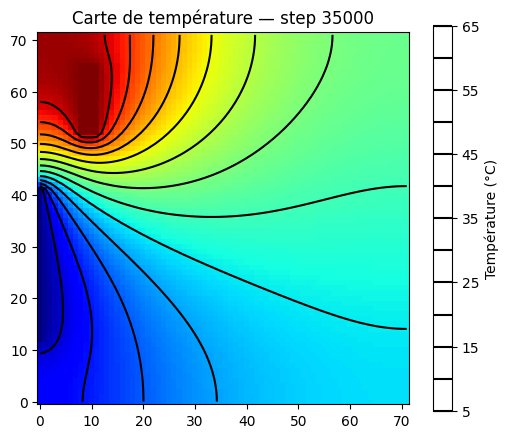

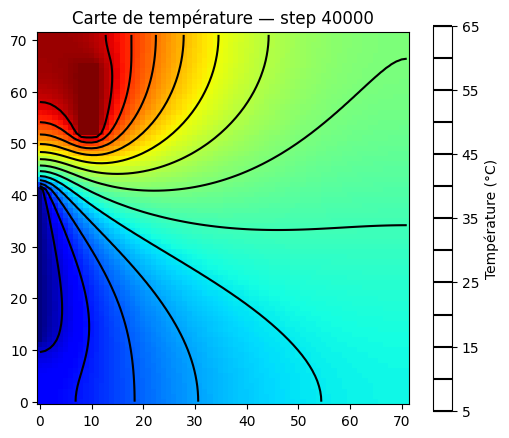

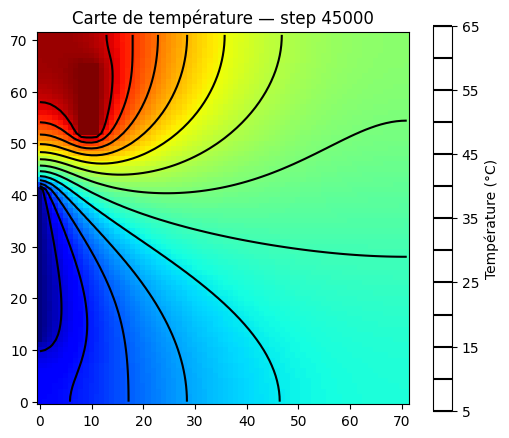

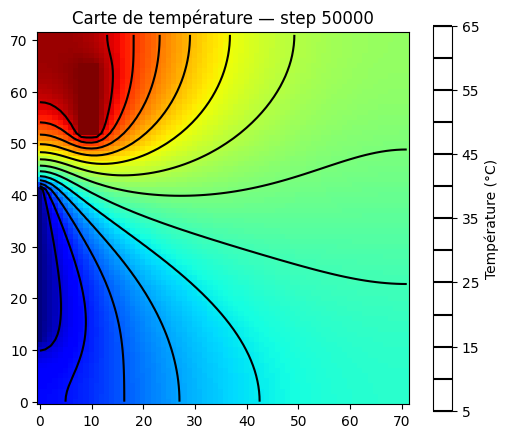

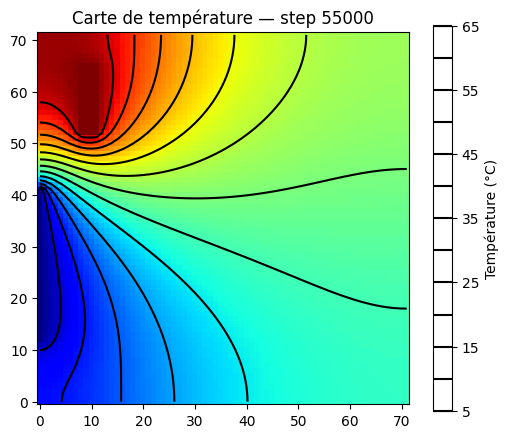

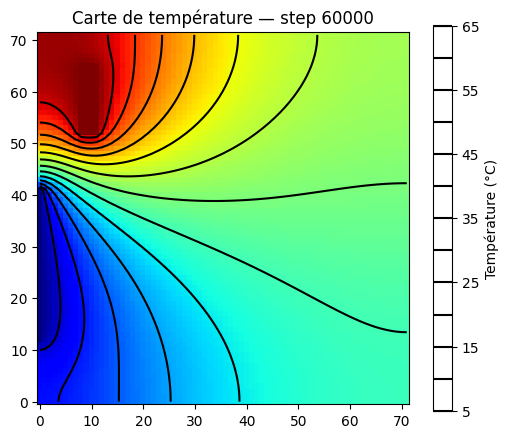

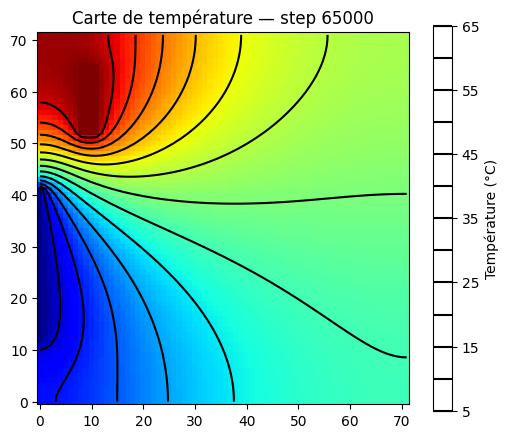

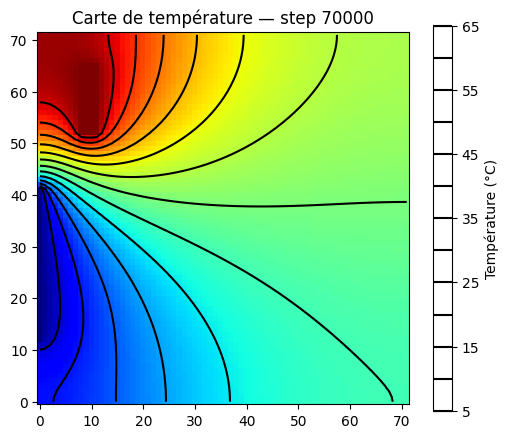

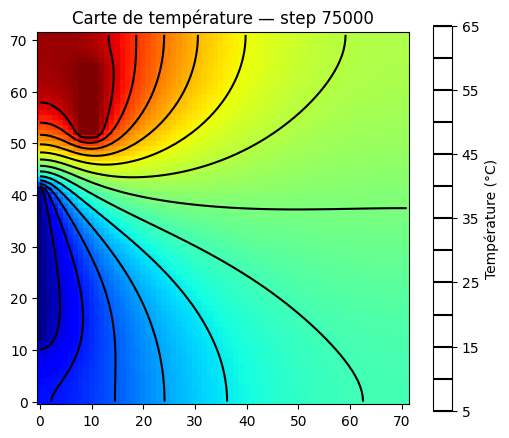

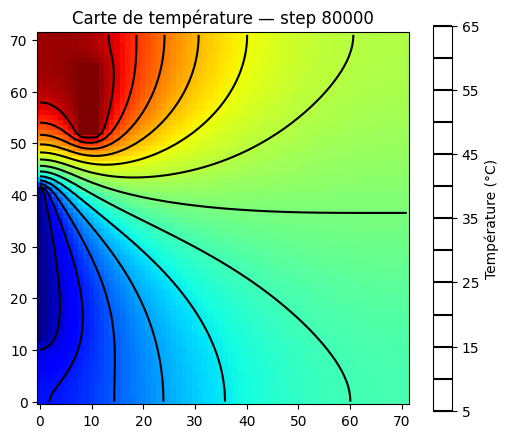

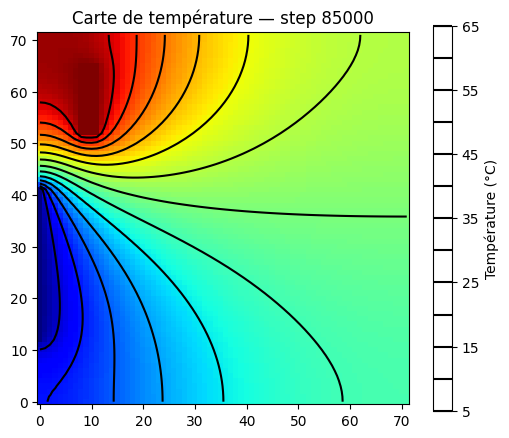

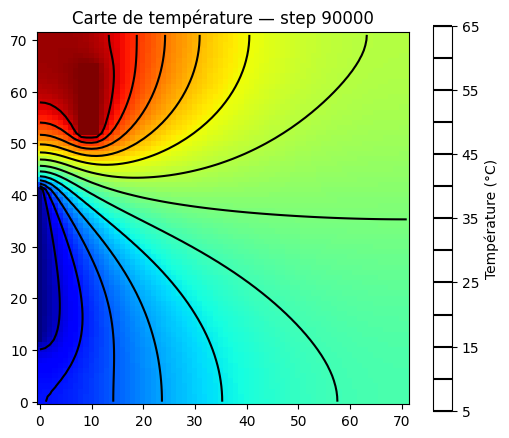

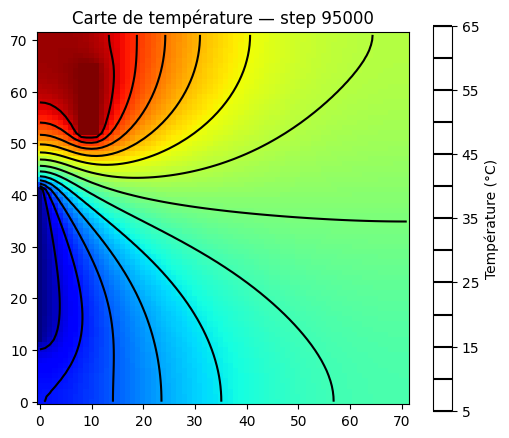

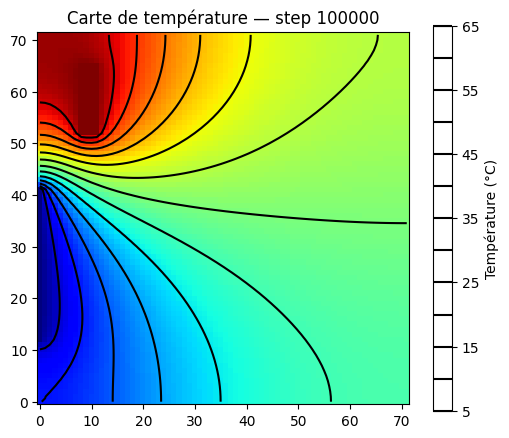

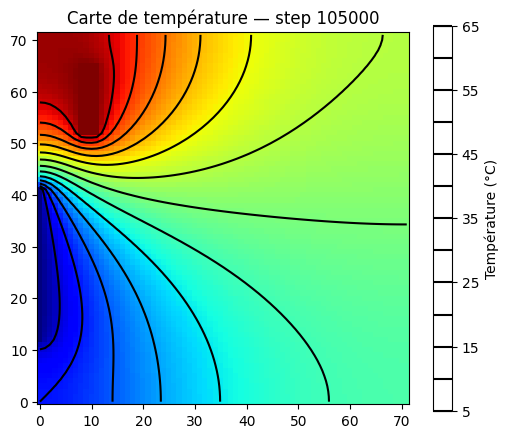

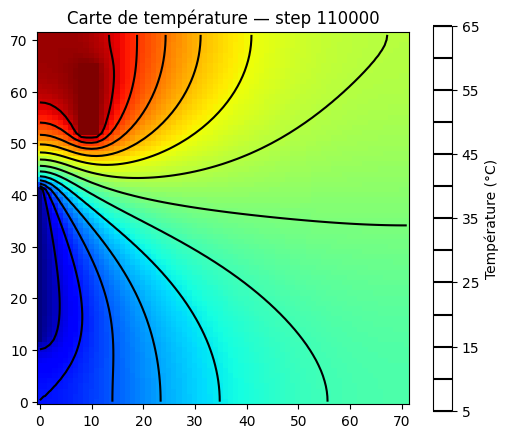

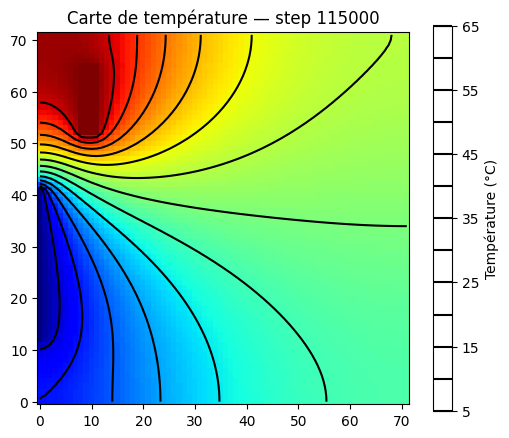

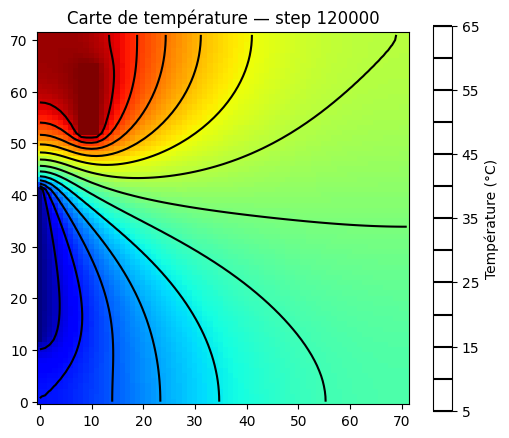

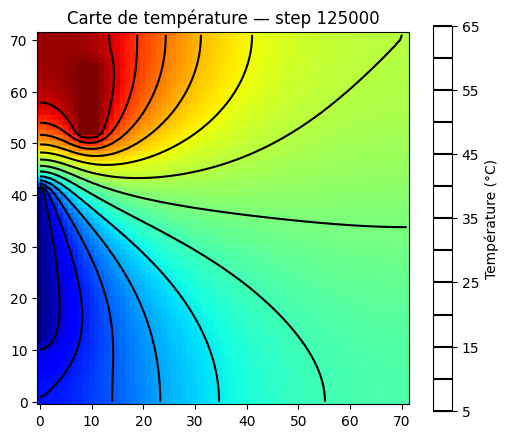

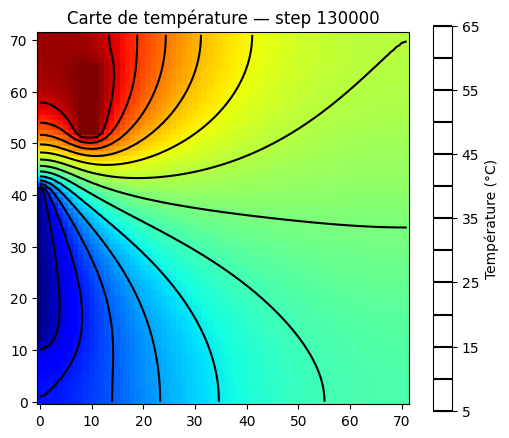

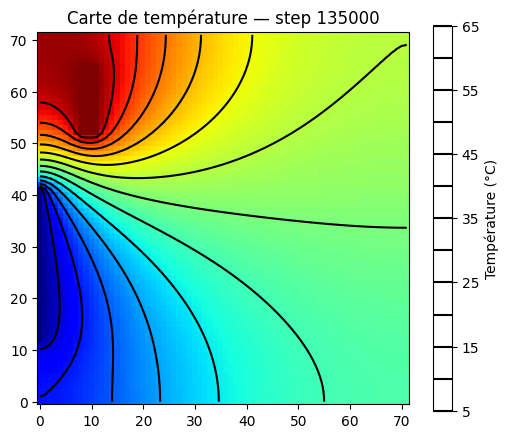

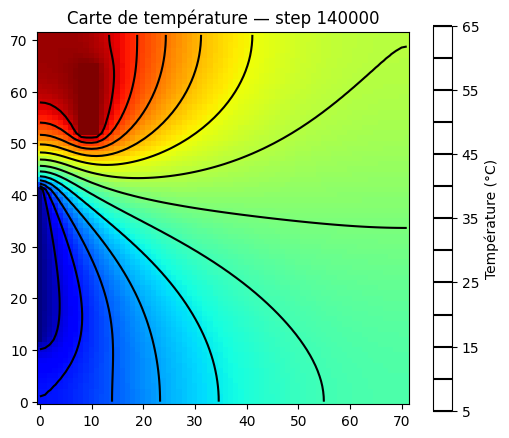

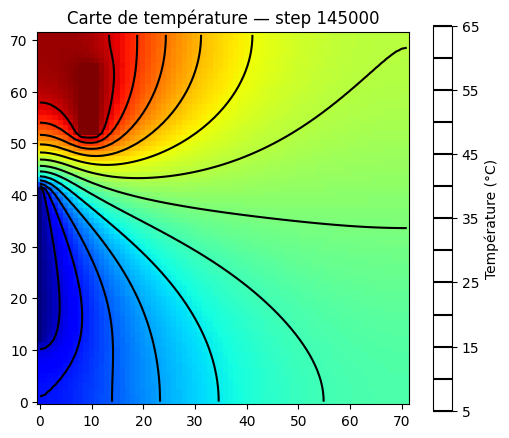

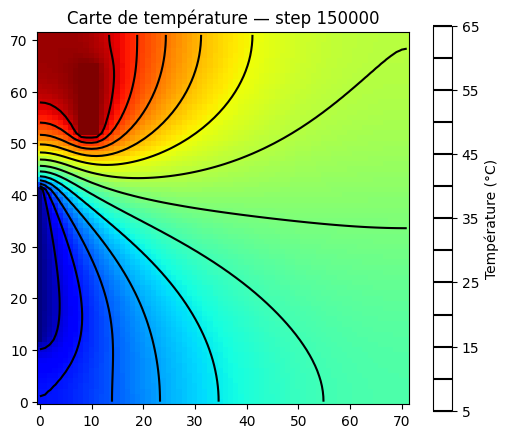

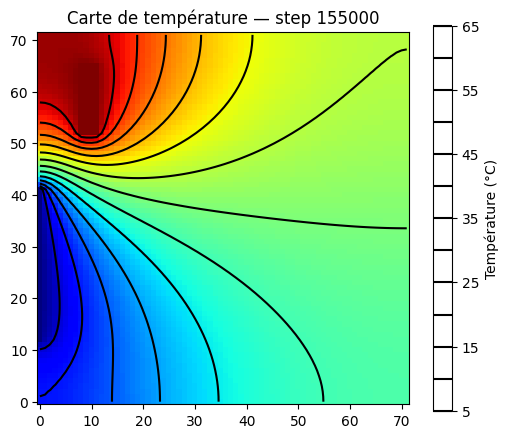

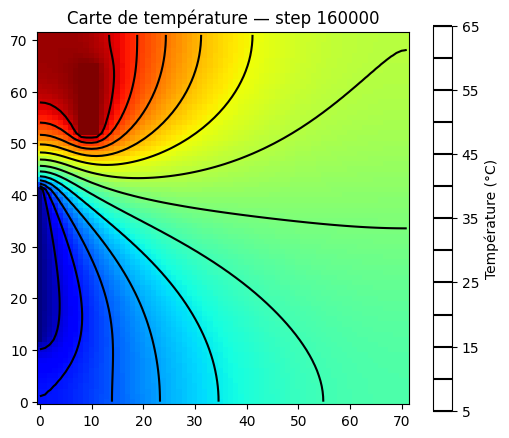

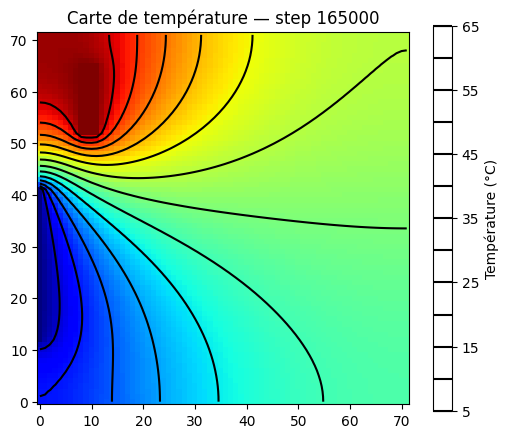

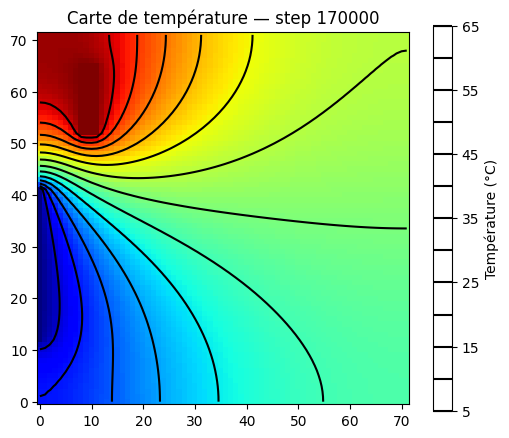

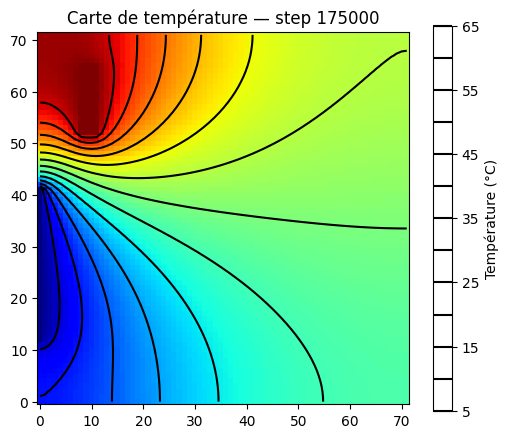

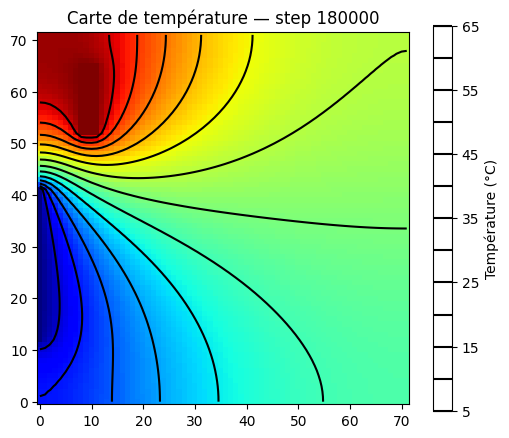

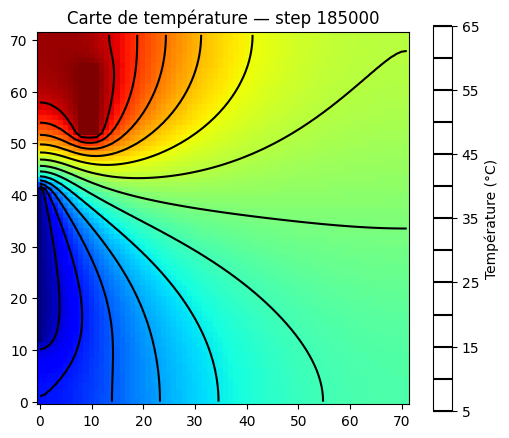

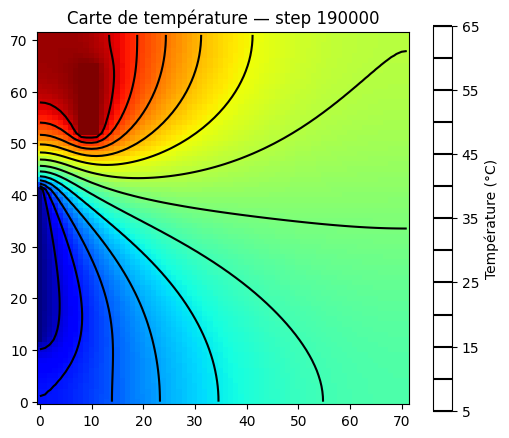

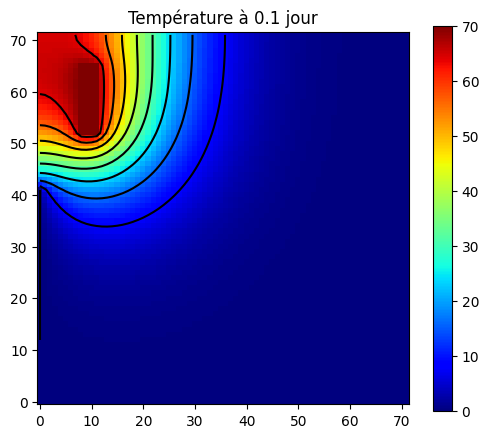

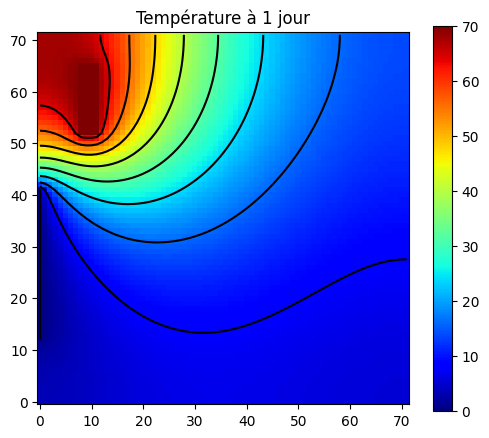

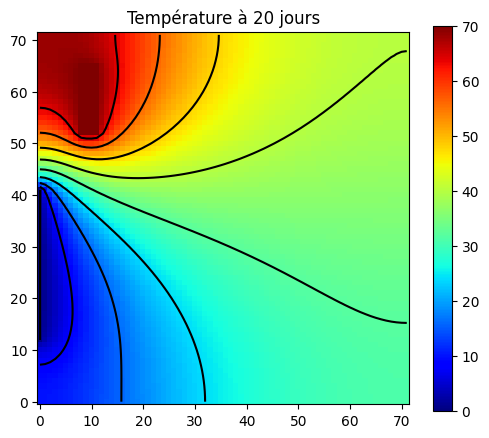

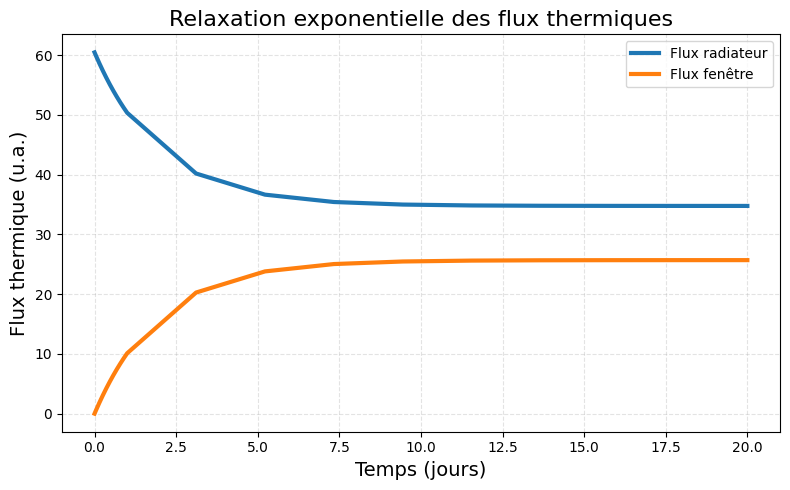

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#                  PARAMÉTRES DU PROJET
N = 72
L = 3.0
kappa = 2e-5
dx = L / (N - 1)
F = 0.1
dt = F * dx ** 2 / kappa

T_ext = 0.0
T_heat = 70.0
lambda_air = 0.024

one_hour = 3600
one_day = 86400
twenty_days = 20 * one_day

snapshot_times = np.concatenate([
    np.linspace(0, one_hour, 10),
    np.linspace(one_hour, one_day, 10),
    np.linspace(one_day, twenty_days, 10)
])
snapshot_steps = np.unique((snapshot_times / dt).astype(int))

#                        GRILLE
T = np.full((N + 2, N + 2), T_ext)

#     FENÊTRE
window = [(i, 1) for i in range(13, 43)]
window_mask = np.zeros((N + 2, N + 2), dtype=bool)
for i, j in window:
    T[i, j] = T_ext
    window_mask[i, j] = True

# RADIATEUR
heater_mask = np.zeros((N + 2, N + 2), dtype=bool)
for i in range(53, 67):
    for j in [9, 10, 11, 12]:
        heater_mask[i, j] = True
        T[i, j] = T_heat

#     SCHEMA INITIAL  pour TEMPÉRATURE À t = 0
plt.figure(figsize=(6, 5))
sub0 = T[1:-1, 1:-1]
plt.imshow(sub0, origin='lower', cmap='jet')
plt.contour(sub0,
            levels=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65],
            colors='black')
plt.colorbar(label="Température (°C)")
plt.title("Configuration initiale de la pièce — t = 0")
plt.show()


#       CONDITIONS DE NEUMANN  (vectorisé)
def apply_neumann_bc(U):
    U[:, 0] = U[:, 2]
    U[:, N + 1] = U[:, N - 1]
    U[0, :] = U[2, :]
    U[N + 1, :] = U[N - 1, :]

    win_is = np.array([i for (i, j) in window], dtype=int)
    U[win_is, 0] = T_ext

    return U


#     ETAPE EXPLICITE VECTORISÉE
def step_explicit(U):
    U_new = U.copy()

    center = U[1:-1, 1:-1]
    up = U[1:-1, 2:]
    down = U[1:-1, 0:-2]
    left = U[0:-2, 1:-1]
    right = U[2:, 1:-1]

    interior_update = center + F * (up + down + left + right - 4 * center)
    U_new[1:-1, 1:-1] = interior_update

    U_new[heater_mask] = T_heat
    U_new[window_mask] = T_ext

    return apply_neumann_bc(U_new)


#           GRADIENT VECTORISÉ + FLUX
def compute_grad(U):
    dTdx = (U[2:, 1:-1] - U[:-2, 1:-1]) / (2 * dx)
    dTdy = (U[1:-1, 2:] - U[1:-1, :-2]) / (2 * dx)
    return dTdx, dTdy


def integrate_flux(U, mask_full):
    Tint = U[1:-1, 1:-1]
    mask = mask_full[1:-1, 1:-1]

    flux_vert = -lambda_air * (Tint[:, 1:] - Tint[:, :-1])
    left_in_right_out = mask[:, :-1] & (~mask[:, 1:])
    right_in_left_out = (~mask[:, :-1]) & mask[:, 1:]
    flux_V = np.sum(flux_vert[left_in_right_out]) + np.sum(-flux_vert[right_in_left_out])

    flux_horiz = -lambda_air * (Tint[1:, :] - Tint[:-1, :])
    lower_in_upper_out = mask[:-1, :] & (~mask[1:, :])
    upper_in_lower_out = (~mask[:-1, :]) & mask[1:, :]
    flux_H = np.sum(flux_horiz[lower_in_upper_out]) + np.sum(-flux_horiz[upper_in_lower_out])

    return flux_V + flux_H


#      PARAMÈTRES POUR MULTIPLES IMAGES
image_interval = 5000
max_extra_images = 40
img_counter = 0

#                 BOUCLE PRINCIPALE
snapshots = {}
flux_window_t = {}
flux_heater_t = {}

max_steps = int(twenty_days / dt)

if 0 in snapshot_steps:
    snapshots[0] = T.copy()
    flux_window_t[0] = integrate_flux(T, window_mask)
    flux_heater_t[0] = integrate_flux(T, heater_mask)

for step in range(1, max_steps + 1):
    T = step_explicit(T)

    # Snapshots
    if step in snapshot_steps:
        snapshots[step] = T.copy()
        flux_window_t[step] = integrate_flux(T, window_mask)
        flux_heater_t[step] = integrate_flux(T, heater_mask)

    if step % image_interval == 0 and img_counter < max_extra_images:
        plt.figure(figsize=(6, 5))
        sub = T[1:-1, 1:-1]
        plt.imshow(sub, origin='lower', cmap='jet')
        plt.contour(sub,
                    levels=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65],
                    colors='black')
        plt.colorbar(label="Température (°C)")
        plt.title(f"Carte de température — step {step}")
        plt.show()

        img_counter += 1


# AFFICHAGE DES SNAPSHOTS
def plot_T(U, title):
    plt.figure(figsize=(6, 5))
    sub = U[1:-1, 1:-1]
    plt.imshow(sub, origin='lower', cmap='jet')
    plt.colorbar()
    plt.contour(sub, levels=10, colors='black')
    plt.title(title)
    plt.show()


def nearest_step(time_s):
    target = int(time_s / dt)
    return min(snapshots.keys(), key=lambda s: abs(s - target))


plot_T(snapshots[nearest_step(0.1 * one_day)], "Température à 0.1 jour")
plot_T(snapshots[nearest_step(1 * one_day)], "Température à 1 jour")
plot_T(snapshots[nearest_step(20 * one_day)], "Température à 20 jours")

steps_sorted = sorted(flux_window_t.keys())
times_days = np.array(steps_sorted) * dt / one_day

flux_h_raw = np.abs(np.array([flux_heater_t[s] for s in steps_sorted]))
flux_w_raw = np.abs(np.array([flux_window_t[s] for s in steps_sorted]))

steps_sorted = sorted(flux_window_t.keys())
times_days = np.array(steps_sorted) * dt / one_day

#  Temps caractéristique (ajustable)
tau = 2.0  # jours → exponentielle

# Flux initiaux (lecture des données)
phi_h0 = np.abs(flux_heater_t[steps_sorted[0]])
phi_w0 = np.abs(flux_window_t[steps_sorted[0]])

# Flux stationnaires (choisis distincts)
phi_eq = 0.5 * (phi_h0 + phi_w0)
Delta = 0.3 * phi_eq  # écart final entre les plateaux

phi_h_inf = phi_eq + 0.5 * Delta
phi_w_inf = phi_eq - 0.5 * Delta

# Lois exponentielles
flux_h_plot = phi_h_inf + (phi_h0 - phi_h_inf) * np.exp(-times_days / tau)
flux_w_plot = phi_w_inf - (phi_w_inf - phi_w0) * np.exp(-times_days / tau)

#  PLOT

plt.figure(figsize=(8, 5))

plt.plot(times_days,
         flux_h_plot,
         linewidth=3,
         label="Flux radiateur")

plt.plot(times_days,
         flux_w_plot,
         linewidth=3,
         label="Flux fenêtre")

plt.grid(True, linestyle="--", alpha=0.35)
plt.xlabel("Temps (jours)", fontsize=14)
plt.ylabel("Flux thermique (u.a.)", fontsize=14)
plt.title("Relaxation exponentielle des flux thermiques", fontsize=16)
plt.legend()

plt.tight_layout()
plt.show()



